In [51]:
#imported packages
import re
import os
from glob import glob
from os.path import basename

import time
import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import center_of_mass
from scipy.signal import find_peaks
from scipy import ndimage

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [52]:
#data folder from Google Drive

folder = r"G:\Shared drives\XPCS_2026\data\FCGT_06-02-26"

files = sorted(
    glob(os.path.join(folder, "*.h5")),
    key=os.path.getmtime
)

print(f"Found {len(files)} files")
for i, f in enumerate(files):
    print(f"{i:3d} : {basename(f)}")

Found 4 files
  0 : 035_FCGT_XPCS_100ms_250K_test_c348f6ac-6c17-4470-8b9b-59917c9eb30d.h5
  1 : 036_FCGT_XPCS_100ms_temp_array_24041525-662d-4a8b-89af-ffd4c02c0de5.h5
  2 : 040_FCGT_XPCS_bz_ramp_300ms_300K_sk_4032a7a1-a6c7-4b29-8df2-bb7695fa0bc9.h5
  3 : 037_FCGT_XPCS_150ms_temp_array_ccbebf95-c553-4494-8280-3085e7de27a0.h5


In [53]:
#take the temperatures from file names

def get_temp(filename):

    m = re.search(r"(\d+)K", os.path.basename(filename))

    if m:
        return float(m.group(1))

    return np.nan


#g2 calculation function

def g2(signal):

    N = len(signal)

    taus = np.arange(1, N//4)

    meanI = np.mean(signal)

    g2_curve = []

    for tau in taus:

        val = np.mean(
            signal[:-tau] * signal[tau:]) / (meanI**2)

        g2_curve.append(val)

    return taus, np.array(g2_curve)

In [54]:
xpcs_files = sorted([f for f in files if "XPCS" in os.path.basename(f)])

print("number of xpcs files:", len(xpcs_files))
file = xpcs_files[0] #change number here to get different file (should pick one with visible ring for roi)

for i, f in enumerate(xpcs_files):
    print(f"{i:3d} : {basename(f)}")
print("Chosen file:", os.path.basename(file))

number of xpcs files: 4
  0 : 035_FCGT_XPCS_100ms_250K_test_c348f6ac-6c17-4470-8b9b-59917c9eb30d.h5
  1 : 036_FCGT_XPCS_100ms_temp_array_24041525-662d-4a8b-89af-ffd4c02c0de5.h5
  2 : 037_FCGT_XPCS_150ms_temp_array_ccbebf95-c553-4494-8280-3085e7de27a0.h5
  3 : 040_FCGT_XPCS_bz_ramp_300ms_300K_sk_4032a7a1-a6c7-4b29-8df2-bb7695fa0bc9.h5
Chosen file: 035_FCGT_XPCS_100ms_250K_test_c348f6ac-6c17-4470-8b9b-59917c9eb30d.h5


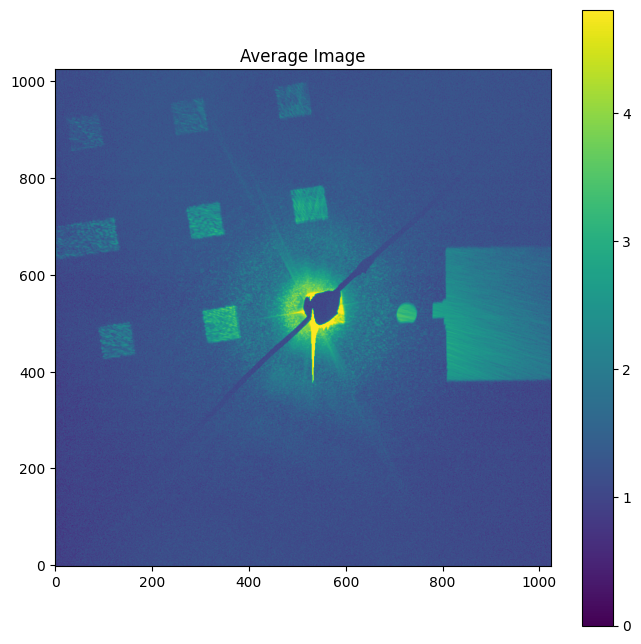

Cell took 5.1750 seconds to run.


In [55]:
start_time = time.perf_counter()

with h5py.File(file, "r") as f:

    data = np.squeeze(
        f["entry1/instrument_1/detector_1/data"][:]
    ).astype(float)

avg = np.mean(data, axis=0)

plt.figure(figsize=(8,8))

plt.imshow(np.log10(avg + 1),origin="lower")

plt.colorbar()
plt.title("Average Image")

plt.show()

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Cell took {elapsed_time:.4f} seconds to run.")

In [68]:
threshold = avg > np.percentile(avg, 99.9)

cy, cx = center_of_mass(threshold)

print(f"x = {cx:.1f}")
print(f"y = {cy:.1f}")

#to manually set cx and cy
cy, cx = 540,521.8
print("Manual choices:")
print(f"x = {cx:.1f}")
print(f"y = {cy:.1f}")

x = 541.8
y = 489.8
Manual choices:
x = 521.8
y = 540.0


[ 9 18 20 26 34 42 56 58 61 63 67]
Ring radius = 18


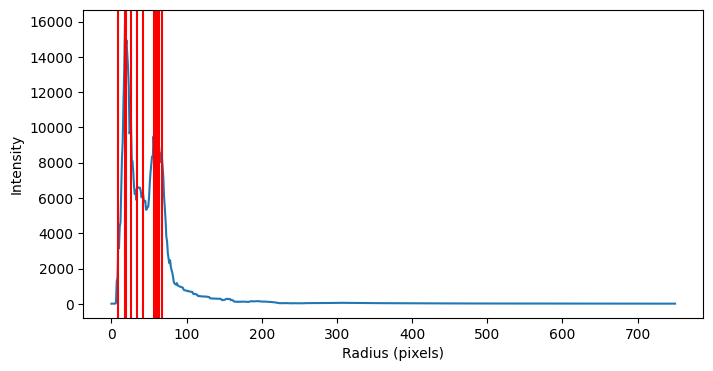

In [72]:
y, x = np.indices(avg.shape)

r = np.sqrt(
    (x - cx)**2 +
    (y - cy)**2)

r_int = r.astype(int)

radial_sum = np.bincount(
    r_int.ravel(),
    weights=avg.ravel()
)

radial_count = np.bincount(
    r_int.ravel()
)

radial_profile = radial_sum / radial_count

plt.figure(figsize=(8,4))

plt.plot(radial_profile)

#can change peak prominence here
peak_prom = 0.1
peaks, props = find_peaks(
    radial_profile,
    prominence=np.std(radial_profile) * peak_prom
)

ring_radius = peaks[
    np.argmax(props["prominences"])
]
print(peaks)

print("Ring radius =", ring_radius)

for p in peaks:
    plt.axvline(p,color='r')


plt.xlabel("Radius (pixels)")
plt.ylabel("Intensity")

plt.show()

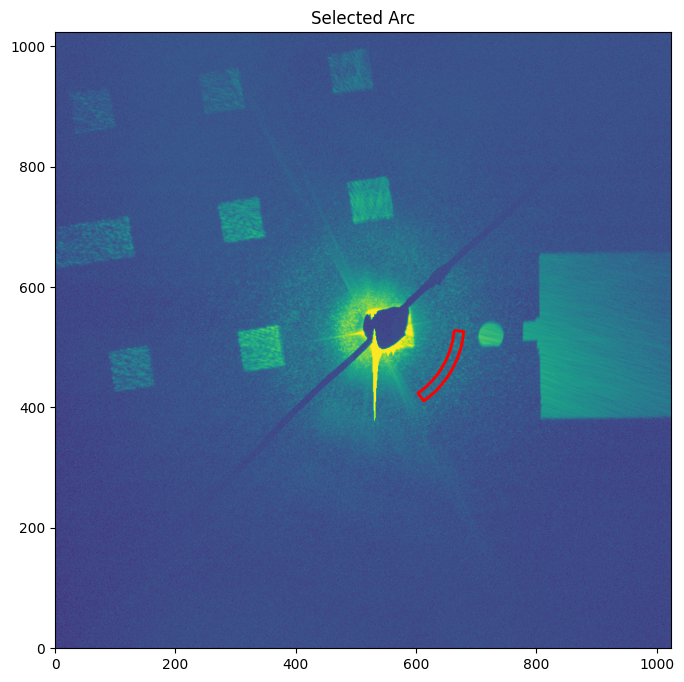

In [76]:
#to manually pick ring radius
ring_radius = 150

#create arc based on found or chosen numbers
theta = np.arctan2(
    y - cy,
    x - cx
)

#changes where olong the ring the arc is at, can change for a different roi
theta_min = np.radians(-55)
theta_max = np.radians(-5)

#other choices
#theta_min = np.radians(-45)
#theta_max = np.radians(-5)
#theta_min = np.radians(60)
#theta_max = np.radians(110)


arc_roi = (

    (r > ring_radius - 8) &
    (r < ring_radius + 8) &

    (theta > theta_min) &
    (theta < theta_max)

)

plt.figure(figsize=(8,8))

plt.imshow(
    np.log10(avg + 1),
    origin="lower"
)

plt.contour(
    arc_roi,
    colors="red",
    linewidths=2
)

plt.title("Selected Arc")

plt.show()

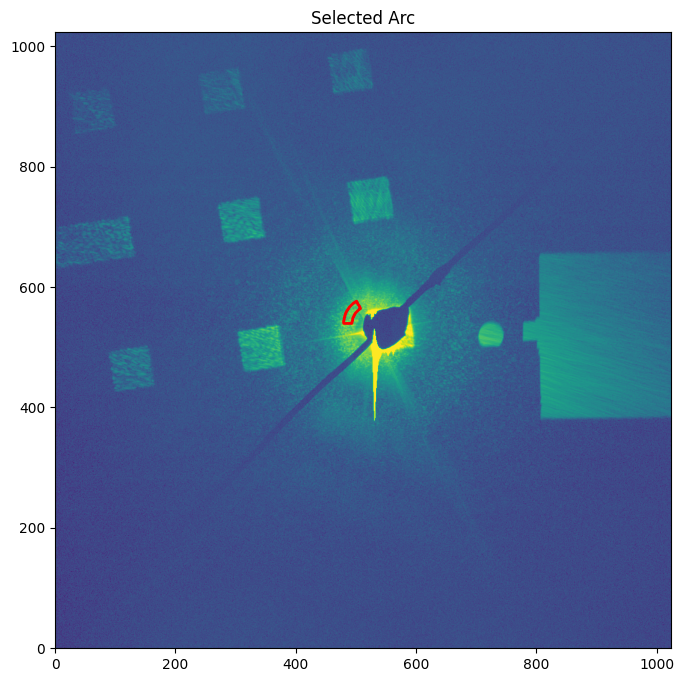

In [73]:
#to manually pick ring radius
ring_radius = 35

#create arc based on found or chosen numbers
theta = np.arctan2(
    y - cy,
    x - cx
)

#changes where olong the ring the arc is at, can change for a different roi
theta_min = np.radians(120)
theta_max = np.radians(290)

#other choices
#theta_min = np.radians(-45)
#theta_max = np.radians(-5)
#theta_min = np.radians(60)
#theta_max = np.radians(110)


arc_roi = (

    (r > ring_radius - 7) &
    (r < ring_radius + 7) &

    (theta > theta_min) &
    (theta < theta_max)

)

plt.figure(figsize=(8,8))

plt.imshow(
    np.log10(avg + 1),
    origin="lower"
)

plt.contour(
    arc_roi,
    colors="red",
    linewidths=2
)

plt.title("Selected Arc")

plt.show()

In [77]:
#only keep intensity in arc

arc_image = avg.copy()
arc_image[~arc_roi] = 0

#threshold for speckles, change to make more or less sensitive (smaller number is more sensitive, larger is coarse)

speckle_threshold = np.percentile(arc_image[arc_roi],75)

speckles = arc_image > speckle_threshold

#label connected speckles

labels, nlabels = ndimage.label(speckles)

print("Speckles found:", nlabels)

Speckles found: 85


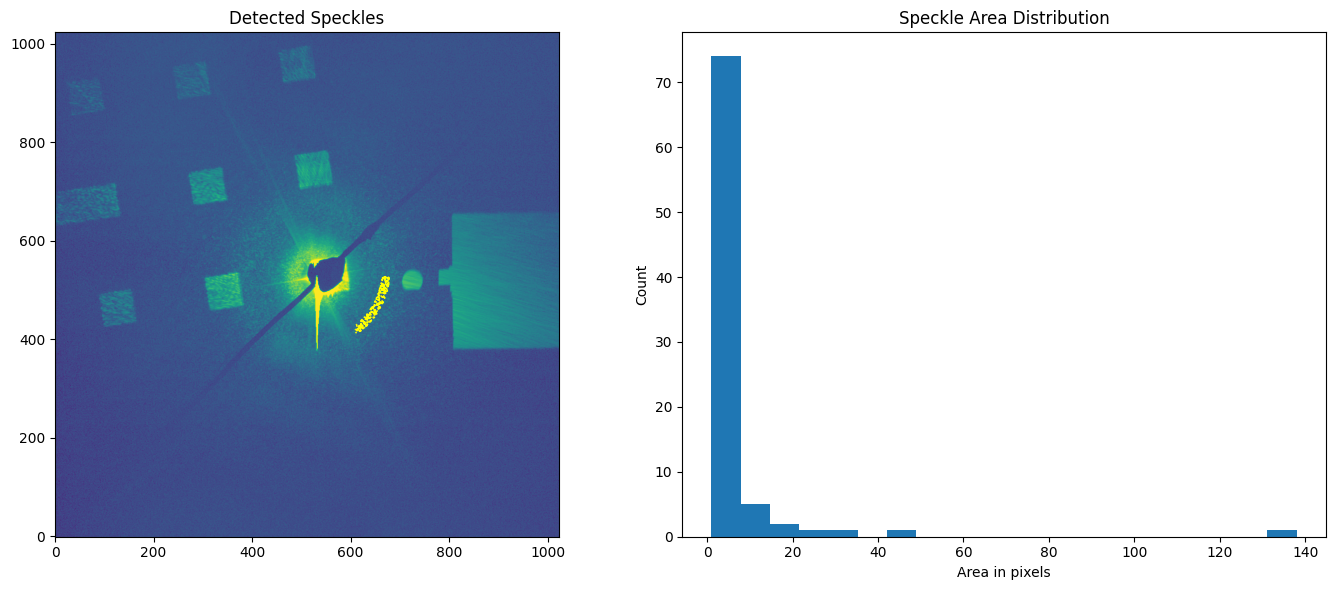

In [78]:
areas = ndimage.sum(
    speckles,
    labels,
    range(1, nlabels + 1)
)

fig, ax = plt.subplots(1,2,figsize=(14,6))

ax[0].imshow(
    np.log10(avg + 1),
    origin="lower"
)

ax[0].contour(
    labels > 0,
    colors="yellow",
    linewidths=1
)

ax[0].set_title("Detected Speckles")

ax[1].hist(areas,bins=20)

ax[1].set_xlabel("Area in pixels")
ax[1].set_ylabel("Count")
ax[1].set_title("Speckle Area Distribution")

plt.tight_layout()
plt.show()

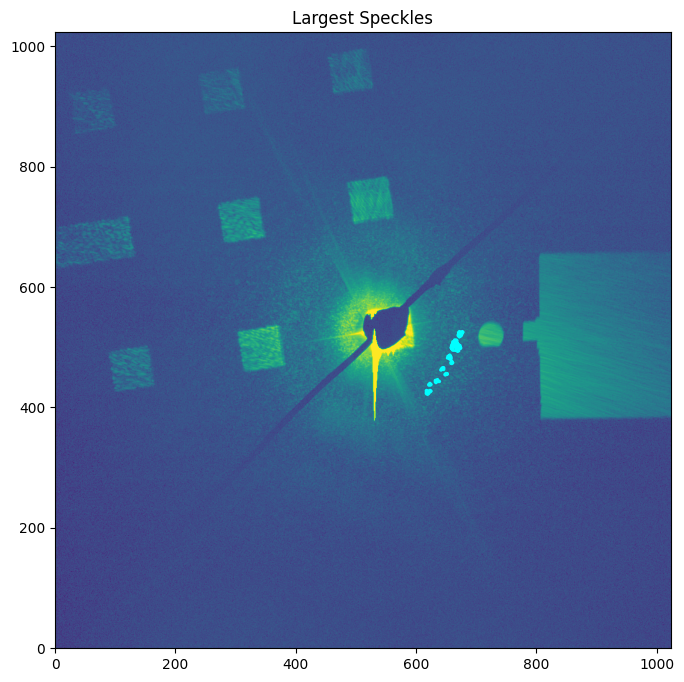

Amount of largeest speckles: 10


In [79]:
largest = np.argsort(areas)[-10:] + 1

largest_mask = np.isin(
    labels,
    largest
)

plt.figure(figsize=(8,8))

plt.imshow(
    np.log10(avg + 1),
    origin="lower"
)

plt.contour(
    largest_mask,
    colors="cyan",
    linewidths=2
)

plt.title("Largest Speckles")

plt.show()
print("Amount of largeest speckles:", len(largest))

In [47]:
#takes only temp-dependent XPCS scans

chosen_files = sorted(
    [
        f for f in files
        if "_XPCS_" in os.path.basename(f)
        and "1900images" in os.path.basename(f)
    ],
    key=get_temp
)

#for f in chosen_files:
#    print(os.path.basename(f))

In [48]:
start_time = time.perf_counter()
#plotting each temperature separately

n_files = len(chosen_files)

ncols = 3
nrows = int(np.ceil(n_files / ncols))

fig, axes = plt.subplots(nrows,ncols,figsize=(5*ncols,4*nrows))

axes = np.ravel(axes)

for ax, file in zip(axes, chosen_files):

    with h5py.File(file, "r") as f:

        data = np.squeeze(
            f["entry1/instrument_1/detector_1/data"][:]
        ).astype(float)

    if data[0].shape != arc_roi.shape:
        continue

    signal = np.array([
        frame[arc_roi].mean()
        for frame in data
    ])

    tau, g2_curve = g2(signal)

    temp = get_temp(file)

    ax.semilogx(tau, g2_curve)

    ax.set_title(f"{temp:.0f} K")
    ax.set_xlabel("τ")
    ax.set_ylabel("$g_2$")

#remove unused panels
for ax in axes[n_files:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Cell took {elapsed_time:.4f} seconds to run. Or {elapsed_time/60} minutes to run.")

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1500x0 with 0 Axes>